<a href="https://colab.research.google.com/github/Ruchikasbn/ruchikasbn/blob/main/6FindingDuplicates_Completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Finding Duplicates Lab**

## Objectives
1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.

In [7]:
!pip install pandas
!pip install matplotlib

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

## Load the dataset

In [9]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

---
## Task 1: Identify Duplicate Rows

In [10]:
# 1a. Count the number of fully duplicate rows
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")
print(f"Total rows in dataset:    {len(df)}")
print(f"Unique rows:              {len(df) - num_duplicates}")

Number of duplicate rows: 20
Total rows in dataset:    65457
Unique rows:              65437


In [11]:
# 1b. Display the first few duplicate rows
duplicate_rows = df[df.duplicated(keep=False)]   # keep=False marks ALL copies
print(f"\nRows involved in full duplication: {len(duplicate_rows)}")
duplicate_rows.head(10)


Rows involved in full duplication: 40


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
5,6,I code primarily as a hobby,Under 18 years old,"Student, full-time",NaN,Apples,NaN,Primary/elementary school,"School (i.e., University, College, etc);Online...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
6,7,"I am not primarily a developer, but I write co...",35-44 years old,"Employed, full-time",Remote,Apples,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Written...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,NaN
7,8,I am learning to code,18-24 years old,"Student, full-time;Not employed, but looking f...",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Video-based Online Cou...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Difficult,NaN,NaN
8,9,I code primarily as a hobby,45-54 years old,"Employed, full-time",In-person,Apples,Hobby,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Other online resources ...,Stack Overflow;Written-based Online Courses,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN
9,10,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN


---
## Task 2: Analysis of Duplicate Response Patterns

Identify groups of respondents who share identical answers for `MainBranch`, `Employment`, and `RemoteWork`.

In [12]:
pattern_cols = ['MainBranch', 'Employment', 'RemoteWork']

# Mark all rows that share the same response pattern in these 3 columns
shared_pattern_mask = df.duplicated(subset=pattern_cols, keep=False)
shared_pattern_df   = df[shared_pattern_mask]

print(f"Rows sharing a response pattern in {pattern_cols}: {len(shared_pattern_df)}")

# Top 10 most common patterns
pattern_counts = (
    df.groupby(pattern_cols, dropna=False)
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
)
print("\nTop 10 most frequent response patterns:")
print(pattern_counts.head(10).to_string(index=False))

Rows sharing a response pattern in ['MainBranch', 'Employment', 'RemoteWork']: 65290

Top 10 most frequent response patterns:
                                                                           MainBranch                                                               Employment                           RemoteWork  count
                                                       I am a developer by profession                                                      Employed, full-time Hybrid (some remote, some in-person)  15288
                                                       I am a developer by profession                                                      Employed, full-time                               Remote  12196
                                                       I am a developer by profession                                                      Employed, full-time                            In-person   7118
                                                       I am a 

In [14]:
other_cols = [c for c in df.columns if c not in pattern_cols]

print("Proportion of identical values per column within shared-pattern groups:\n")
for col in other_cols:
    # Within each pattern group, what fraction of rows have only one unique value for this column?
    consistency = (
        shared_pattern_df.groupby(pattern_cols)[col]
        .apply(lambda x: (x.nunique(dropna=False) == 1))
        .mean()
    )
    print(f"  {col:<40} {consistency:.2%}")

Proportion of identical values per column within shared-pattern groups:

  ResponseId                               0.00%
  Age                                      9.40%
  Check                                    100.00%
  CodingActivities                         0.31%
  EdLevel                                  3.76%
  LearnCode                                1.25%
  LearnCodeOnline                          2.19%
  TechDoc                                  5.02%
  YearsCode                                1.25%
  YearsCodePro                             45.14%
  DevType                                  2.19%
  OrgSize                                  47.34%
  PurchaseInfluence                        48.90%
  BuyNewTool                               44.83%
  BuildvsBuy                               50.47%
  TechEndorse                              44.51%
  Country                                  3.13%
  Currency                                 45.77%
  CompTotal                         

---
## Task 3: Visualize Shared Response Patterns

/tmp/ipykernel_14008/3485739120.py:26: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


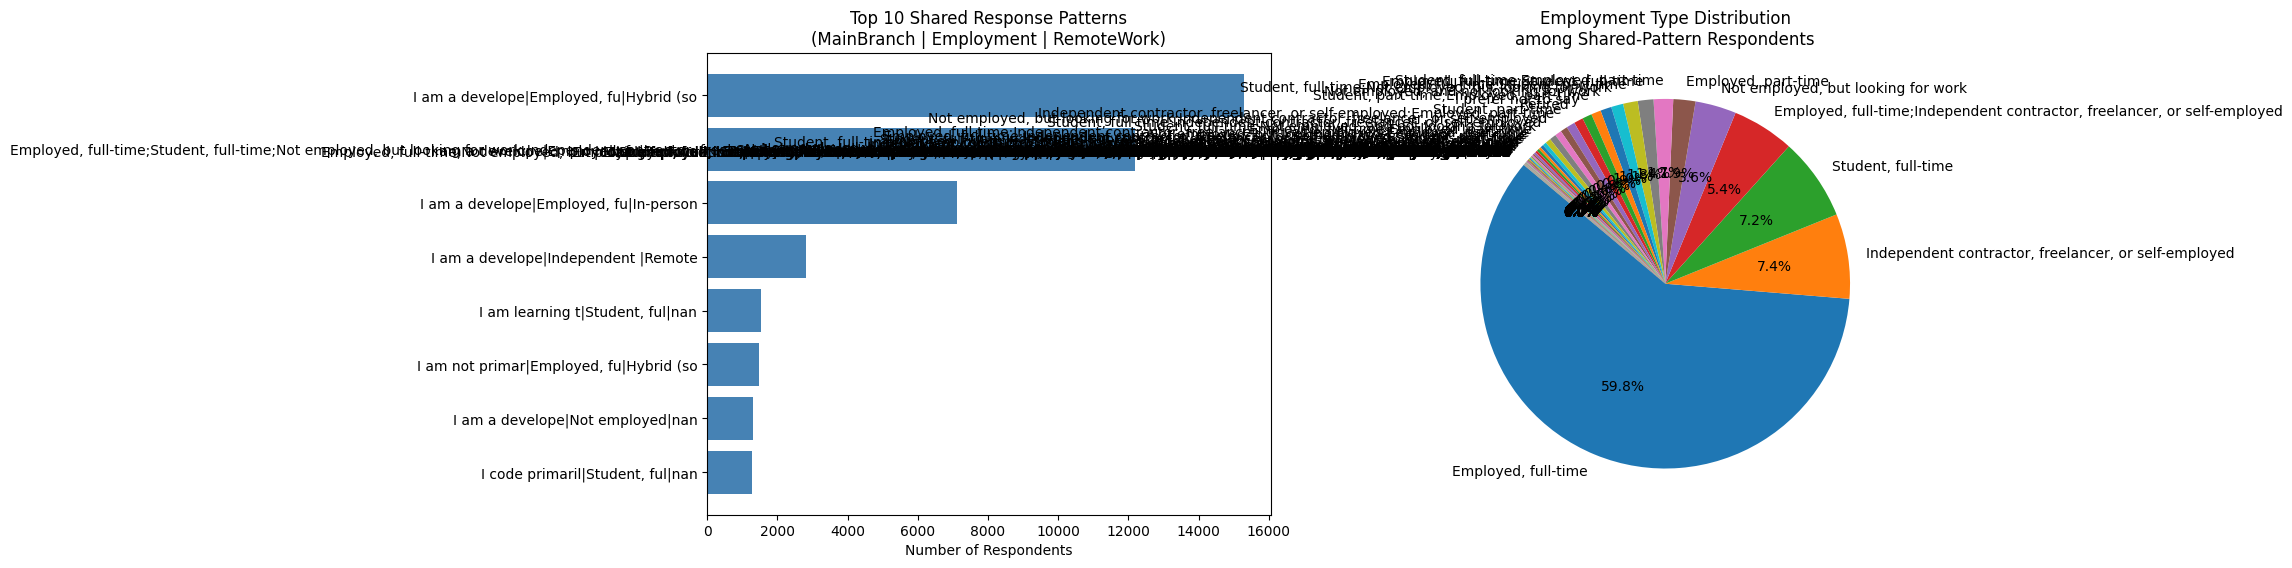

Chart saved to duplicate_patterns.png


In [18]:
# ---- Bar chart: top 10 patterns by count ----
top10 = pattern_counts.head(10).copy()
top10['pattern_label'] = top10.apply(
    lambda r: f"{str(r['MainBranch'])[:15]}|{str(r['Employment'])[:12]}|{str(r['RemoteWork'])[:10]}",
    axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
axes[0].barh(top10['pattern_label'], top10['count'], color='steelblue')
axes[0].set_xlabel('Number of Respondents')
axes[0].set_title('Top 10 Shared Response Patterns\n(MainBranch | Employment | RemoteWork)')
axes[0].invert_yaxis()

# Pie chart — distribution by Employment type among shared-pattern rows
employment_dist = shared_pattern_df['Employment'].value_counts()
axes[1].pie(
    employment_dist.values,
    labels=employment_dist.index,
    autopct='%1.1f%%',
    startangle=140
)
axes[1].set_title('Employment Type Distribution\namong Shared-Pattern Respondents')

plt.tight_layout()
plt.savefig('duplicate_patterns.png', dpi=120)
plt.show()
print("Chart saved to duplicate_patterns.png")

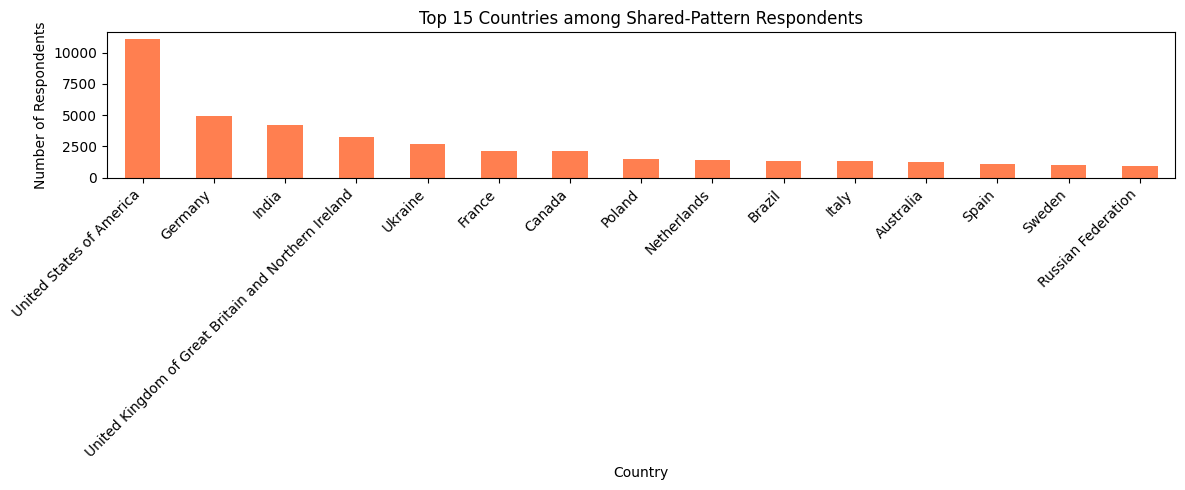

In [17]:
# Bar chart: respondents sharing patterns grouped by Country (top 15)
country_counts = shared_pattern_df['Country'].value_counts().head(15)

plt.figure(figsize=(12, 5))
country_counts.plot(kind='bar', color='coral')
plt.title('Top 15 Countries among Shared-Pattern Respondents')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('shared_patterns_by_country.png', dpi=120)
plt.show()

---
## Task 4: Evaluate Duplicate Handling Strategy

**Which column(s) define record uniqueness?**

Survey datasets typically include a unique `ResponseId` (or equivalent) column that uniquely identifies each submission. Let's verify:

In [21]:
# Check candidate identifier columns
id_candidates = [c for c in df.columns if 'id' in c.lower() or 'response' in c.lower()]
print("Candidate identifier columns:", id_candidates)

for col in id_candidates:
    n_unique = df[col].nunique()
    print(f"  {col}: {n_unique} unique values out of {len(df)} rows")

Candidate identifier columns: ['ResponseId']
  ResponseId: 65437 unique values out of 65457 rows


In [20]:
# Remove fully duplicate rows and verify
df_clean = df.drop_duplicates()
print(f"Rows before deduplication: {len(df)}")
print(f"Rows after  deduplication: {len(df_clean)}")
print(f"Rows removed:              {len(df) - len(df_clean)}")
print(f"Remaining duplicates:      {df_clean.duplicated().sum()}")

Rows before deduplication: 65457
Rows after  deduplication: 65437
Rows removed:              20
Remaining duplicates:      0


---
## Task 5: Documentation

### 5a. Process of identifying and removing duplicates

### 5b. Reasoning behind selecting specific columns for deduplication